In [ ]:
# =========================================================
# 1. IMPORT PUSTAKA & MOUNT GOOGLE DRIVE
# =========================================================
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Pustaka Machine Learning & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Pustaka untuk Oversampling
from imblearn.over_sampling import RandomOverSampler

drive.mount('/content/drive')
print("✅ Proses 1 Selesai: Pustaka dan Google Drive siap!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Proses 1 Selesai: Pustaka dan Google Drive siap!


In [ ]:
# =========================================================
# 2. PERSIAPAN SUBSET DATASET (200 & 350) MURNI
# =========================================================

source_dir = '/content/drive/MyDrive/Colab Notebooks/Citra Daun Padi'

def buat_subset_dataset(nama_folder_tujuan, jumlah_blast, jumlah_blight, jumlah_tungro):
    dest_dir = f'/content/{nama_folder_tujuan}'

    if os.path.exists(dest_dir):
        shutil.rmtree(dest_dir)

    kelas = ['blast', 'blight', 'tungro']
    jumlah_kebutuhan = [jumlah_blast, jumlah_blight, jumlah_tungro]

    for k in kelas:
        os.makedirs(os.path.join(dest_dir, k), exist_ok=True)

    for i, k in enumerate(kelas):
        folder_sumber_kelas = os.path.join(source_dir, k)
        semua_file = [f for f in os.listdir(folder_sumber_kelas) if os.path.isfile(os.path.join(folder_sumber_kelas, f))]

        # Mengambil sampel acak sesuai kebutuhan
        sampel_file = random.sample(semua_file, jumlah_kebutuhan[i])
        folder_tujuan_kelas = os.path.join(dest_dir, k)

        for file in sampel_file:
            src_path = os.path.join(folder_sumber_kelas, file)
            dst_path = os.path.join(folder_tujuan_kelas, file)
            shutil.copy(src_path, dst_path)

    print(f"   ✅ Folder '{nama_folder_tujuan}' berhasil disiapkan di Colab.")

print("\n--- Memulai Penyiapan Subset Folder ---")
buat_subset_dataset('dataset_200', jumlah_blast=120, jumlah_blight=50, jumlah_tungro=30)
buat_subset_dataset('dataset_350', jumlah_blast=150, jumlah_blight=160, jumlah_tungro=40)
buat_subset_dataset('dataset_500', jumlah_blast=200, jumlah_blight=220, jumlah_tungro=80)
print("✅ Proses 2 Selesai: Subset data siap!")


--- Memulai Penyiapan Subset Folder ---
   ✅ Folder 'dataset_200' berhasil disiapkan di Colab.
   ✅ Folder 'dataset_350' berhasil disiapkan di Colab.
   ✅ Folder 'dataset_500' berhasil disiapkan di Colab.
✅ Proses 2 Selesai: Subset data siap!


In [ ]:
import pandas as pd
# =========================================================
# 3. MESIN EKSTRAKSI FITUR (WARNA & BENTUK)
# =========================================================
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv_image], [0], None, [bins[0]], [0, 256])
    hist_saturation = cv2.calcHist([hsv_image], [1], None, [bins[1]], [0, 256])
    hist_value = cv2.calcHist([hsv_image], [2], None, [bins[2]], [0, 256])

    hist_hue = cv2.normalize(hist_hue, hist_hue).flatten()
    hist_saturation = cv2.normalize(hist_saturation, hist_saturation).flatten()
    hist_value = cv2.normalize(hist_value, hist_value).flatten()

    return np.hstack([hist_hue, hist_saturation, hist_value])

def extract_shape_features(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresholded_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresholded_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = sum(cv2.contourArea(c) for c in contours)
    perimeter = sum(cv2.arcLength(c, True) for c in contours)

    return np.array([area, perimeter])

def extract_all_features(image):
    color_features = extract_color_histogram(image)
    shape_features = extract_shape_features(image)
    return np.hstack([color_features, shape_features])

In [ ]:
# =========================================================
# 4. FUNGSI LOAD & EKSTRAK DATA
# =========================================================
def load_and_extract(data_dir, img_size=(224, 224)):
    feature_vectors = []
    labels = []
    classes = ['blast', 'blight', 'tungro']

    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            continue

        for image_file in os.listdir(cls_dir):
            image_path = os.path.join(cls_dir, image_file)
            image = cv2.imread(image_path)

            if image is not None:
                image = cv2.resize(image, img_size)
                features = extract_all_features(image)
                feature_vectors.append(features)
                labels.append(idx)

    return np.array(feature_vectors), np.array(labels), classes

print("✅ Proses 4 Selesai: Fungsi Load Data dikompilasi!")

✅ Proses 4 Selesai: Fungsi Load Data dikompilasi!


In [ ]:
# =========================================================
# 6. PERSIAPAN MODEL MACHINE LEARNING
# =========================================================
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

datasets_bal = {
    'Skenario Balancing 200': '/content/dataset_200',
    'Skenario Balancing 350': '/content/dataset_350',
    'Skenario Balancing 500': '/content/dataset_500'
}
print("✅ Proses 6 Selesai: Model ML siap dilatih!")

✅ Proses 6 Selesai: Model ML siap dilatih!



--- Memproses Dataset Skenario BALANCING (Hybrid Setelah Split) ---


Mengekstrak fitur untuk Skenario Balancing 200...
Distribusi sebelum Balancing (Data Latih) : [96 40 24] | Total: 160
Distribusi sesudah Balancing (Data Latih) : [67 67 66] | Total: 200

--- Hasil Kinerja: Random Forest ---
Akurasi   : 90.00% | Presisi: 88.33% | Recall: 88.33% | F1-Score: 88.33%

--- Hasil Kinerja: SVM ---
Akurasi   : 87.50% | Presisi: 94.25% | Recall: 76.67% | F1-Score: 82.04%

--- Hasil Kinerja: KNN ---
Akurasi   : 77.50% | Presisi: 75.28% | Recall: 79.17% | F1-Score: 75.38%


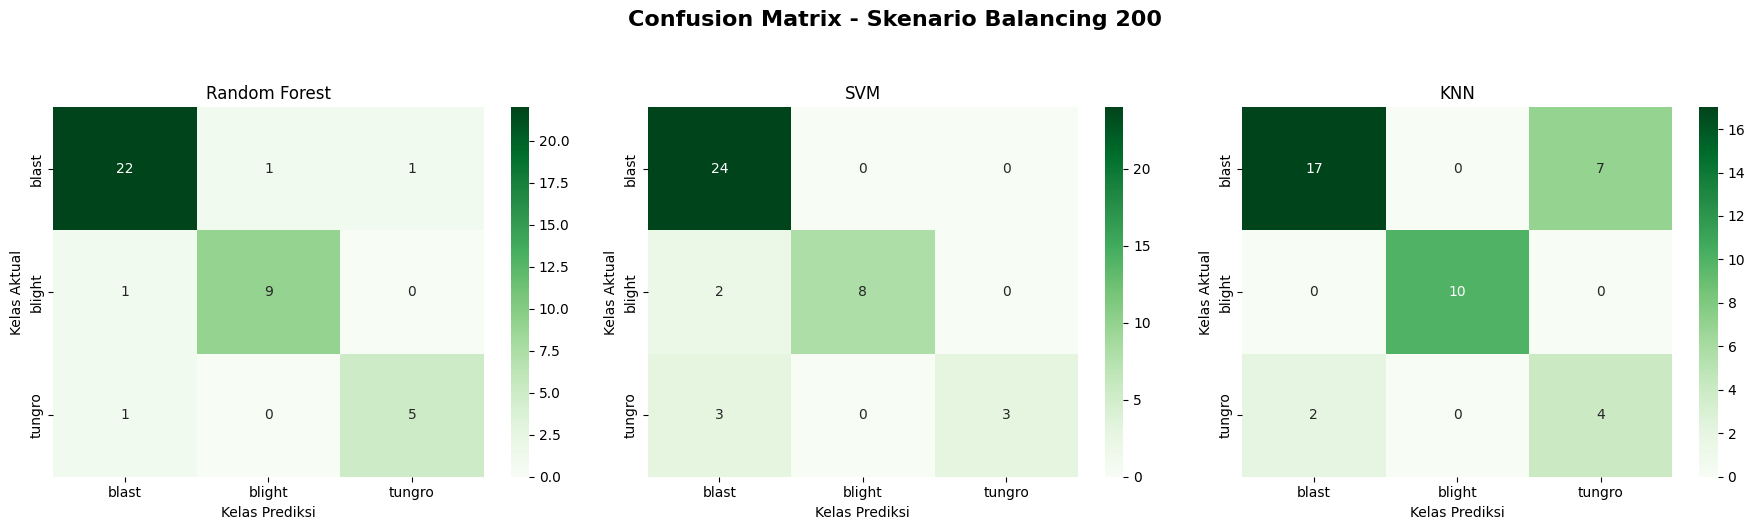


Mengekstrak fitur untuk Skenario Balancing 350...
Distribusi sebelum Balancing (Data Latih) : [120 128  32] | Total: 280
Distribusi sesudah Balancing (Data Latih) : [117 117 116] | Total: 350

--- Hasil Kinerja: Random Forest ---
Akurasi   : 97.14% | Presisi: 95.19% | Recall: 97.85% | F1-Score: 96.40%

--- Hasil Kinerja: SVM ---
Akurasi   : 94.29% | Presisi: 92.71% | Recall: 92.64% | F1-Score: 92.61%

--- Hasil Kinerja: KNN ---
Akurasi   : 82.86% | Presisi: 77.56% | Recall: 80.90% | F1-Score: 78.44%


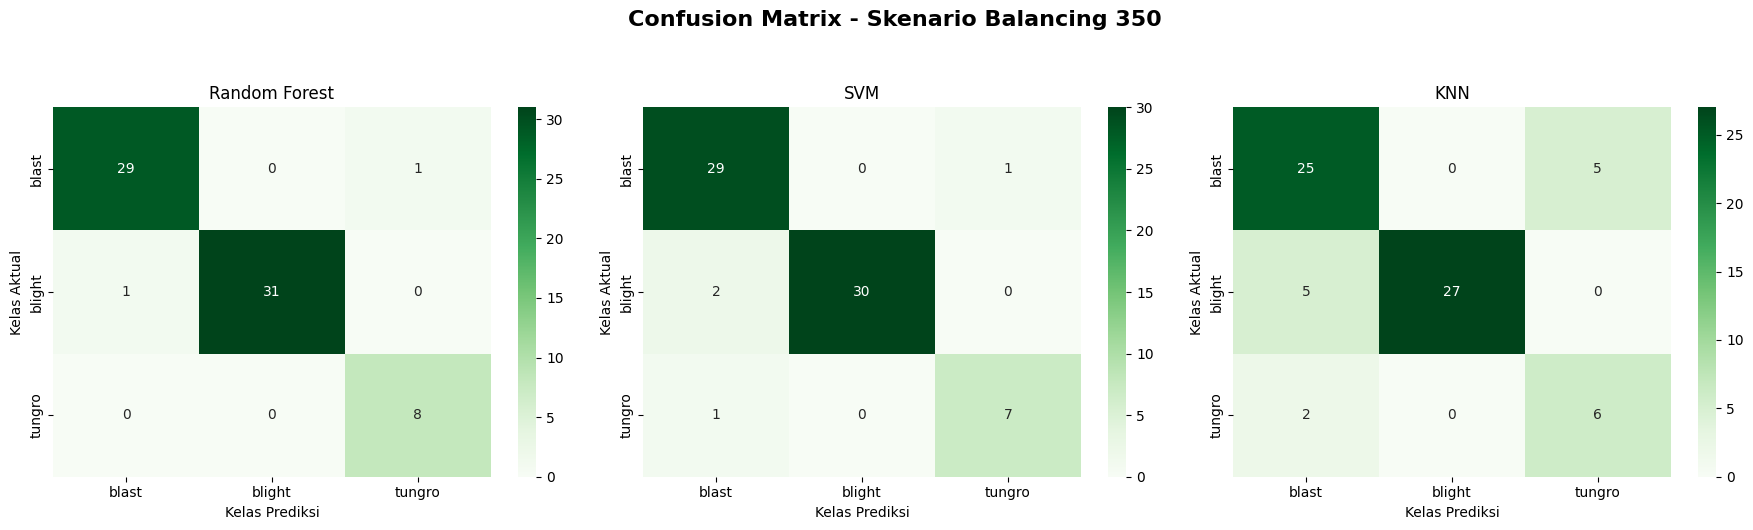


Mengekstrak fitur untuk Skenario Balancing 500...
Distribusi sebelum Balancing (Data Latih) : [160 176  64] | Total: 400
Distribusi sesudah Balancing (Data Latih) : [167 167 166] | Total: 500

--- Hasil Kinerja: Random Forest ---
Akurasi   : 98.00% | Presisi: 97.21% | Recall: 98.41% | F1-Score: 97.77%

--- Hasil Kinerja: SVM ---
Akurasi   : 96.00% | Presisi: 93.59% | Recall: 95.49% | F1-Score: 94.43%

--- Hasil Kinerja: KNN ---
Akurasi   : 92.00% | Presisi: 89.26% | Recall: 90.98% | F1-Score: 90.01%


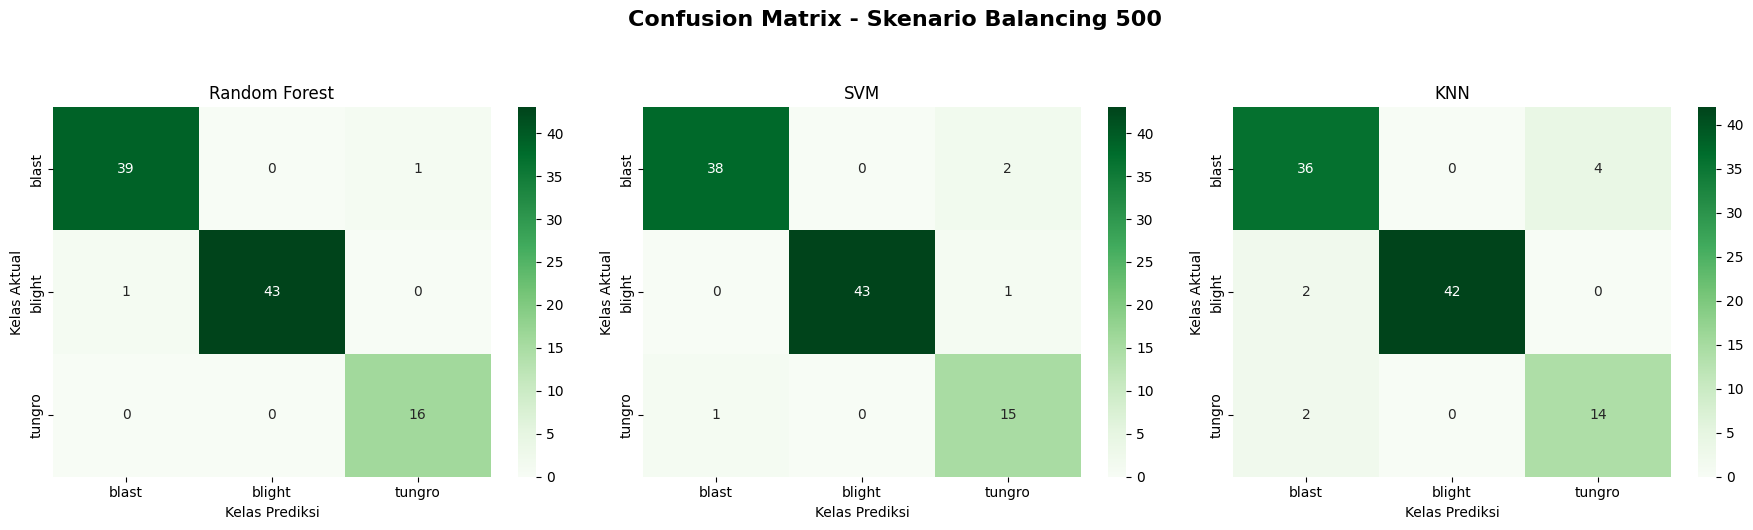

🎉 SELURUH PROSES SELESAI!


In [ ]:
# =========================================================
# 7. SPLIT DATA, BALANCING HYBRID & EVALUASI
# =========================================================
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Memproses Dataset Skenario BALANCING (Hybrid Setelah Split) ---\n")

for ds_name, ds_path in datasets_bal.items():
    print(f"\n{'='*60}")
    print(f"Mengekstrak fitur untuk {ds_name}...")
    X, y, target_names = load_and_extract(ds_path)

    if len(X) == 0:
        print(f"❌ Data kosong di {ds_path}. Pastikan path benar.")
        continue

    # 1. SPLIT DATA (Mencegah Data Leakage)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Distribusi sebelum Balancing (Data Latih) : {np.bincount(y_train)} | Total: {len(y_train)}")

    # =======================================================
    # 2. HYBRID SAMPLING (Menyesuaikan Target Data Latih Pas)
    # =======================================================
    # Tentukan target total data latih berdasarkan nama skenario
    if '200' in ds_name:
        target_total = 200
    elif '350' in ds_name:
        target_total = 350
    else:
        target_total = 500

    # Menghitung porsi per kelas agar rata (misal 200 dibagi 3 kelas)
    classes, counts = np.unique(y_train, return_counts=True)
    target_dict = {}
    sisa = target_total % len(classes)

    for i, c in enumerate(classes):
        target_dict[c] = (target_total // len(classes)) + (1 if i < sisa else 0)

    # Pisahkan tugas Oversampling (menambah) dan Undersampling (memotong)
    dict_over = {}
    dict_under = {}
    current_counts = dict(zip(classes, counts))

    for c in classes:
        if current_counts[c] < target_dict[c]:
            dict_over[c] = target_dict[c]
        elif current_counts[c] > target_dict[c]:
            dict_under[c] = target_dict[c]

    # Eksekusi berurutan menggunakan Pipeline
    langkah = []
    if dict_over:
        langkah.append(('over', RandomOverSampler(sampling_strategy=dict_over, random_state=42)))
    if dict_under:
        langkah.append(('under', RandomUnderSampler(sampling_strategy=dict_under, random_state=42)))

    pipeline = Pipeline(steps=langkah)
    X_train_bal, y_train_bal = pipeline.fit_resample(X_train, y_train)

    print(f"Distribusi sesudah Balancing (Data Latih) : {np.bincount(y_train_bal)} | Total: {len(y_train_bal)}")
    # =======================================================

    # 3. NORMALISASI FITUR (Standard Scaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled = scaler.transform(X_test)

    # 4. PELATIHAN DAN VISUALISASI MATRIKS CONFUSION
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrix - {ds_name}', fontsize=16, fontweight='bold', y=1.05)

    for ax, (model_name, model) in zip(axes, models.items()):

        # Melatih dan Memprediksi
        model.fit(X_train_scaled, y_train_bal)
        y_pred = model.predict(X_test_scaled)

        # Menghitung Metrik
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # Cetak Hasil
        print(f"\n--- Hasil Kinerja: {model_name} ---")
        print(f"Akurasi   : {acc*100:.2f}% | Presisi: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%")

        # Grafik Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names, ax=ax)

        ax.set_title(f'{model_name}')
        ax.set_xlabel('Kelas Prediksi')
        ax.set_ylabel('Kelas Aktual')

    plt.tight_layout()
    plt.show()

print("🎉 SELURUH PROSES SELESAI!")

--- Menyiapkan Visualisasi Transformasi Citra ---


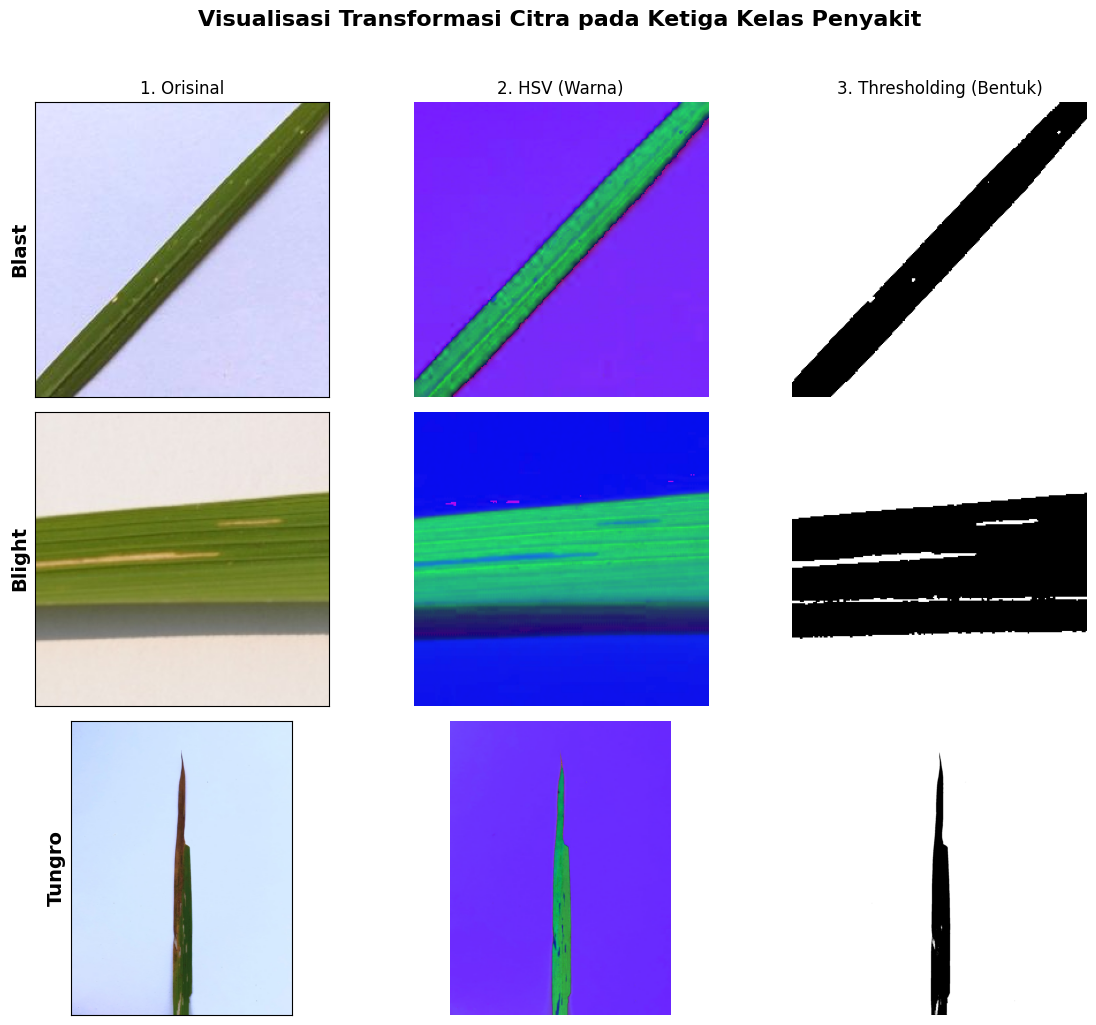

✅ Visualisasi selesai ditampilkan!



In [ ]:
# =========================================================
# CELL 2.5: VISUALISASI TRANSFORMASI CITRA
# =========================================================
import os
import cv2
import matplotlib.pyplot as plt

print("--- Menyiapkan Visualisasi Transformasi Citra ---")

# Mengambil sampel gambar dari folder dataset asli (Non-Balancing)
base_dir_viz = '/content/drive/MyDrive/Colab Notebooks/Citra Daun Padi Non Balancing'
classes_viz = ['Blast', 'Blight', 'Tungro']

# PERBAIKAN 1: Kanvas diubah menjadi 3 baris x 3 kolom agar tidak ada yang kosong
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Visualisasi Transformasi Citra pada Ketiga Kelas Penyakit', fontsize=16, fontweight='bold', y=1.02)

for i, cls in enumerate(classes_viz):
    cls_dir = os.path.join(base_dir_viz, cls)
    if os.path.exists(cls_dir) and len(os.listdir(cls_dir)) > 0:
        # Mengambil 1 gambar pertama dari masing-masing folder penyakit
        sample_file = os.listdir(cls_dir)[0]
        sample_path = os.path.join(cls_dir, sample_file)

        # Membaca gambar orisinal
        img_bgr = cv2.imread(sample_path)
        img_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # PERBAIKAN 2: Menggunakan 'img_bgr' langsung (bukan img_bgr_resized)
        # Proses HSV (Mewakili Fitur Warna)
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

        # Proses Grayscale & Thresholding (Mewakili Fitur Bentuk/Shape)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        _, img_thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

        # Plotting 1. Orisinal (Kolom ke-1, indeks 0)
        axes[i, 0].imshow(img_original)
        axes[i, 0].set_ylabel(cls, fontsize=14, fontweight='bold')
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
        if i == 0: axes[i, 0].set_title('1. Orisinal', fontsize=12)

        # Plotting 2. HSV (Kolom ke-2, indeks 1)
        axes[i, 1].imshow(img_hsv)
        axes[i, 1].axis('off')
        if i == 0: axes[i, 1].set_title('2. HSV (Warna)', fontsize=12)

        # Plotting 3. Thresholding (Kolom ke-3, indeks 2)
        axes[i, 2].imshow(img_thresh, cmap='gray')
        axes[i, 2].axis('off')
        if i == 0: axes[i, 2].set_title('3. Thresholding (Bentuk)', fontsize=12)

plt.tight_layout()
plt.show()
print("✅ Visualisasi selesai ditampilkan!\n")